# Week 11 - Introduction to Modeling, part 2

# 1. Lesson - No lesson this week

# 2. Weekly graph question

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

The book names one of Vonnegut's rules as "keep it simple" and another as "have the guts to cut."  Here is some data from the previous week's lesson.  If you had to cut one of the two plots below, which would it be?  Which seems more interesting or important?  Explain.  (Should "amount of training data used" or "number of estimators" be on the x-axis.)

In [2]:
np.random.seed(0)
num_points = 10000
feature_1a = np.random.random(size = num_points) * 3
feature_2a = np.random.random(size = num_points) * 3
feature_3a = np.random.random(size = num_points) * 3
train_target = (feature_1a - 2 * feature_2a) * feature_3a + np.random.normal(size = num_points)
feature_1b = np.random.random(size = num_points) * 3
feature_2b = np.random.random(size = num_points) * 3
feature_3b = np.random.random(size = num_points) * 3
test_target = (feature_1b - 2 * feature_2b) * feature_3b + np.random.normal(size = num_points)
train_df = pd.DataFrame({"f1": feature_1a, "f2": feature_2a, "f3": feature_3a})
test_df = pd.DataFrame({"f1": feature_1b, "f2": feature_2b, "f3": feature_3b})
rf = RandomForestRegressor()
rf.fit(train_df.values, train_target)

RandomForestRegressor()

In [3]:
rmse_lst = list()
rf = RandomForestRegressor()
for x in range(round(num_points / 20), num_points, round(num_points / 20)):
    rf.fit(train_df.values[0:x,:], train_target[0:x])
    rmse_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

import matplotlib.pyplot as plt

Text(0, 0.5, 'Loss function')

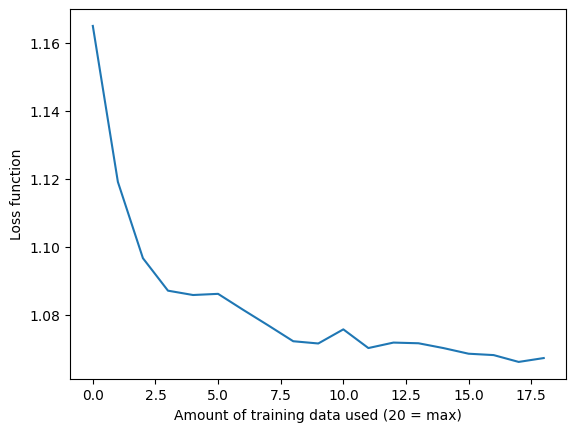

In [4]:
plt.plot(rmse_lst)
plt.xlabel("Amount of training data used (20 = max)")
plt.ylabel("Loss function")

In [5]:
num_trees_lst = list()
for n_estimators in range(1, 100, 3):
    rf = RandomForestRegressor(n_estimators = n_estimators)
    rf.fit(train_df.values, train_target)
    num_trees_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

Text(0, 0.5, 'Loss function')

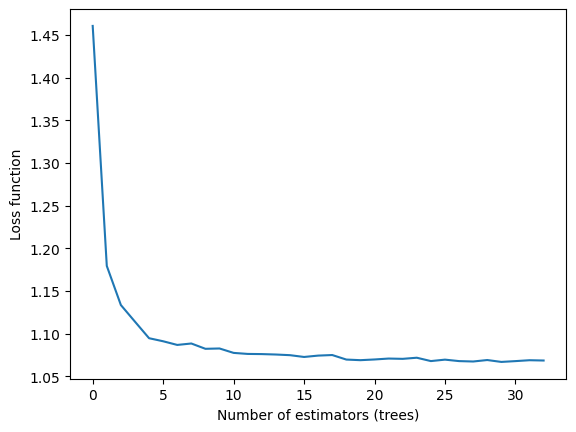

In [6]:
plt.plot(num_trees_lst)
plt.xlabel("Number of estimators (trees)")
plt.ylabel("Loss function")

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:

* Implement a random forest model.
* Perform cross-validation.
* Tune hyperparameters.
* Evaluate a performance metric.

If you like, you can try other types of models, too (beyond linear regression and random forest) although you will have many opportunities to do that next semester.

In [8]:
df = pd.read_csv("./cleaned_datasets/cleaned_diabetes.csv")

In [9]:
df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

In [82]:
# Filter out columns that aren't interesting from the correlation matrix
interesting_columns = ['BMI', 'Age', 'Income', 'Education', 'HvyAlcoholConsump', 'Smoker', 'PhysActivity', 'Diabetes_binary']  # Example columns
filtered_correlation_matrix = df[interesting_columns].corr()
filtered_correlation_matrix

,BMI,Age,Income,Education,HvyAlcoholConsump,Smoker,PhysActivity,Diabetes_binary
BMI,1.000000,-0.036618,-0.100069,-0.103932,-0.048736,0.013804,-0.147294,0.216843
Age,-0.036618,1.000000,-0.127775,-0.101901,-0.034578,0.120641,-0.092511,0.177442
Income,-0.100069,-0.127775,1.000000,0.449106,0.053619,-0.123937,0.198539,-0.163919
Education,-0.103932,-0.101901,0.449106,1.000000,0.023997,-0.161955,0.199658,-0.124456
HvyAlcoholConsump,-0.048736,-0.034578,0.053619,0.023997,1.000000,0.101619,0.012392,-0.057056
Smoker,0.013804,0.120641,-0.123937,-0.161955,0.101619,1.000000,-0.087401,0.060789
PhysActivity,-0.147294,-0.092511,0.198539,0.199658,0.012392,-0.087401,1.000000,-0.118133
Diabetes_binary,0.216843,0.177442,-0.163919,-0.124456,-0.057056,0.060789,-0.118133,1.000000


<Axes: title={'center': 'Correlation Matrix of Selected Features'}>

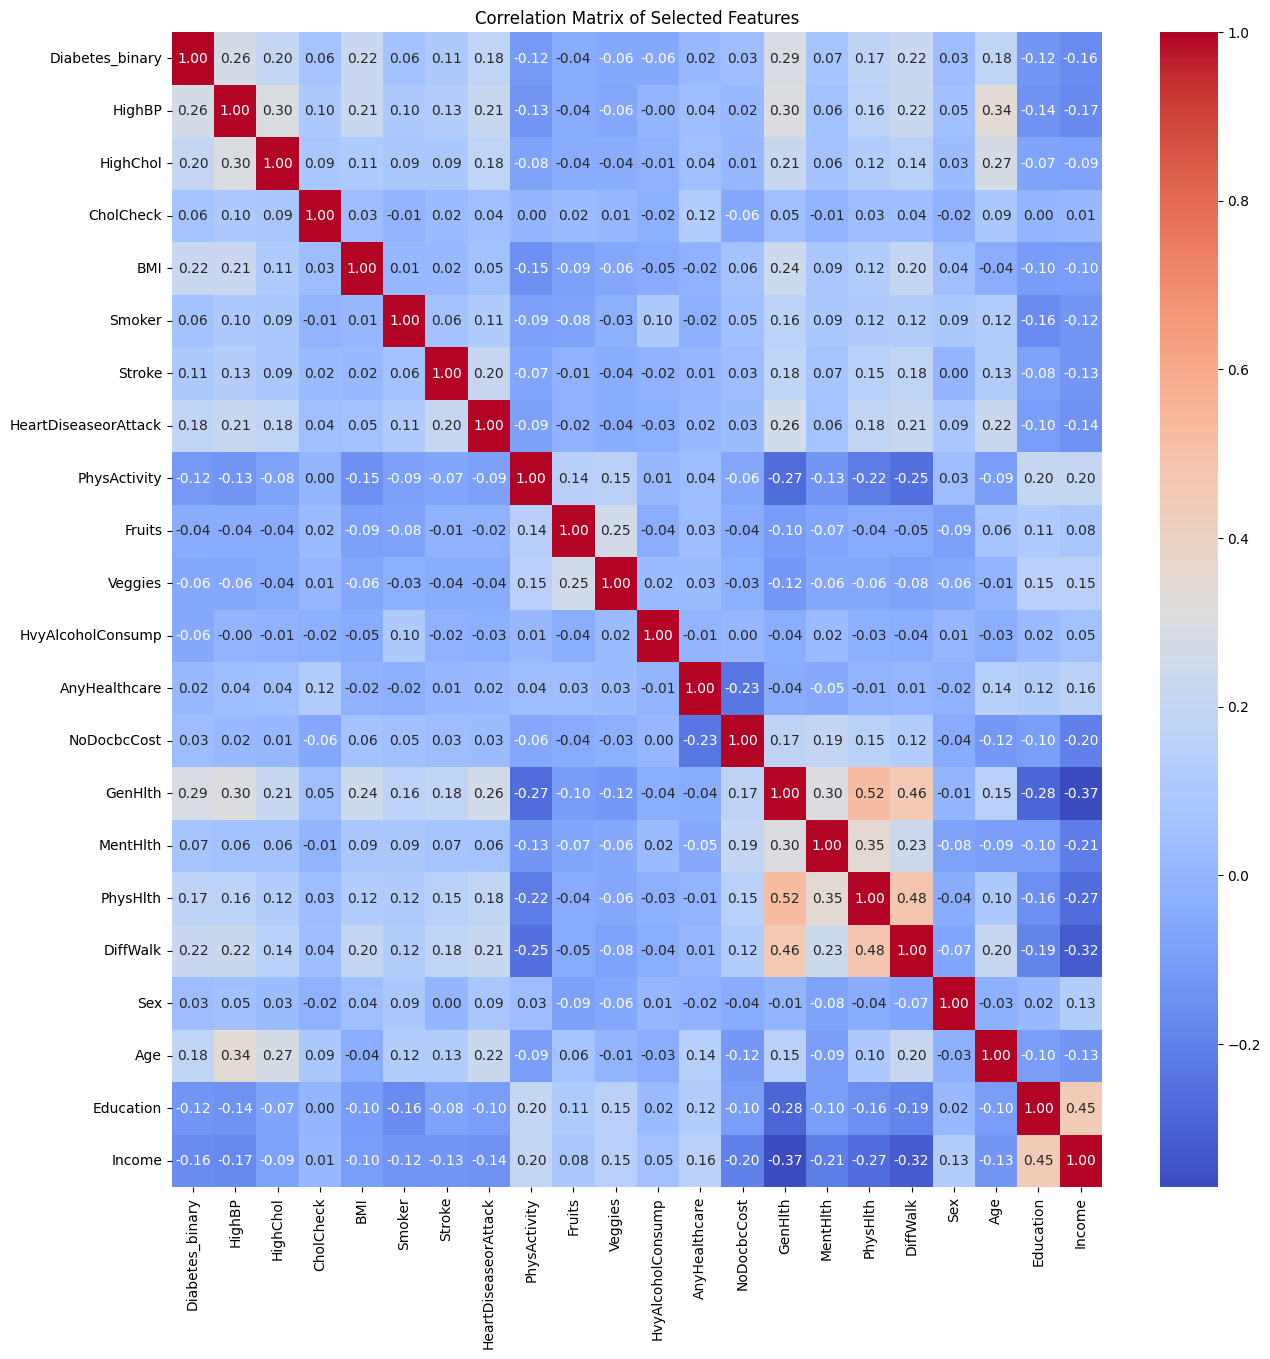

In [92]:
import seaborn as sns
plt.figure(figsize=(15, 15))
plt.title('Correlation Matrix of Selected Features')
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")

<Axes: title={'center': 'Correlation Matrix of Selected Features'}>

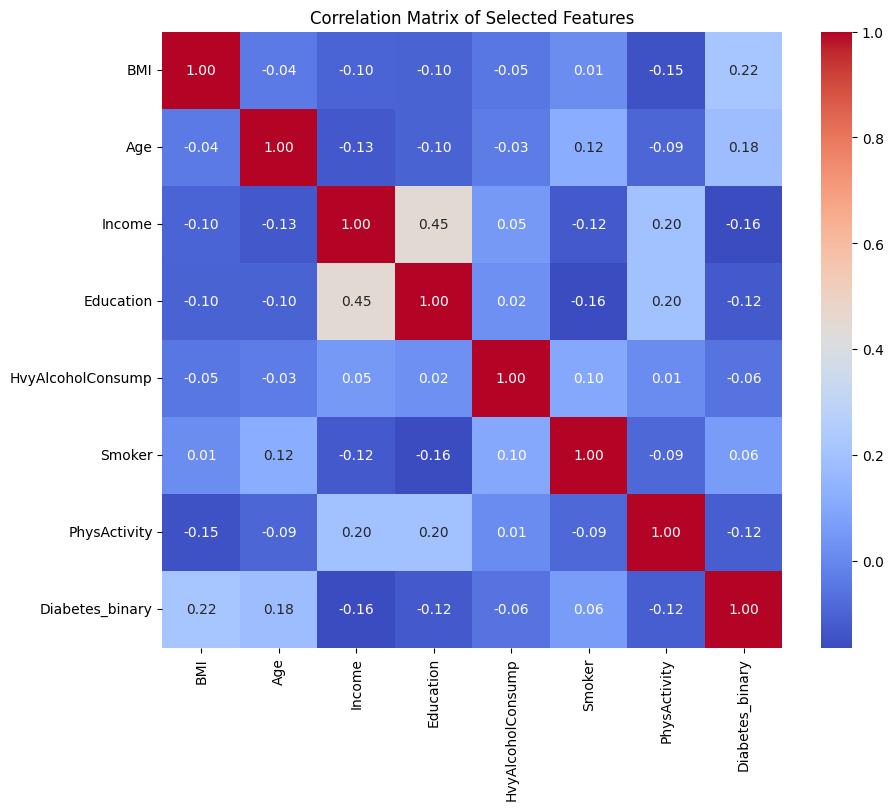

In [85]:

plt.figure(figsize=(10, 8))
plt.title('Correlation Matrix of Selected Features')
sns.heatmap(filtered_correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")

In [93]:
pivot = df.pivot_table(index = ["Age"], columns = ["Smoker"], values = "Diabetes_binary", aggfunc = "count")
pivot

Smoker,0.0,1.0
Age,,
1.0,4455,1245
2.0,5288,2310
3.0,6919,4204
4.0,8315,5508
5.0,10347,5810
6.0,12521,7298
7.0,15240,11074
8.0,16645,14187
9.0,17649,15595


Text(0.5, 1.0, 'Diabetes Cases by Age and Smoking Status')

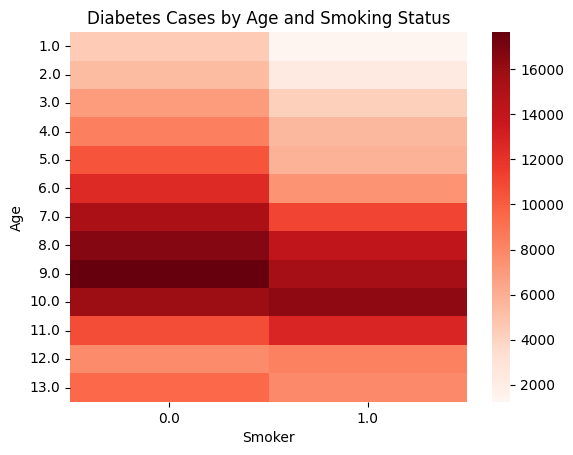

In [89]:
ax = sns.heatmap(pivot, cmap = "Reds")
ax.set_title("Diabetes Cases by Age and Smoking Status")

In [29]:
from sklearn.model_selection import train_test_split


random_seed = 42
y = df["Diabetes_binary"]
X = df.drop("Diabetes_binary", axis=1)


X_train, X_test, y_train, y_test= train_test_split(X, y, test_size = 0.2, random_state = random_seed)

In [44]:
# Import necessary libraries
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, classification_report

# Implement Random Forest model
rfc = RandomForestClassifier(random_state=random_seed, n_jobs=-2, class_weight="balanced")
rfc.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', n_jobs=-2, random_state=42)

In [45]:
import warnings

warnings.filterwarnings("ignore", module="sklearn")

In [49]:
from scipy.stats import randint

skfold = StratifiedKFold(n_splits=5, random_state=random_seed, shuffle=True)


# Tune Hyperparameters using RandomizedSearchCV
param_distributions = {
    'n_estimators': randint(50, 250),  # Adjusted for larger datasets
    'max_depth': [None, 10, 20, 30],  # Added deeper trees for complex data
    'min_samples_split': randint(2, 12),  # Standard values for splitting
    'min_samples_leaf': [1, 2, 4],  # Added leaf size for regularization
    'max_leaf_nodes': [None, 20, 50, 100],  # More options for leaf nodes
    'criterion': ['gini', 'entropy']  # Evaluate both splitting criteria
}
random_search = RandomizedSearchCV(estimator=rfc, param_distributions=param_distributions, cv=skfold, scoring='precision', n_iter=30, random_state=random_seed, n_jobs=-1)
random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)
print("Best Cross-Validation Precision:", random_search.best_score_)

results_df = pd.DataFrame(random_search.cv_results_)

Best Parameters: {'criterion': 'gini', 'max_depth': None, 'max_leaf_nodes': None, 'min_samples_leaf': 1, 'min_samples_split': 8, 'n_estimators': 58}
Best Cross-Validation Precision: 0.41291311808762093


In [54]:
# Sort the models by their mean test score (Precision) in descending order
top_10_models = results_df.sort_values(by='mean_test_score', ascending=False).head(10)

# Select only the most relevant columns so the output isn't overwhelmingly wide
columns_to_show = ['rank_test_score', 'mean_test_score', 'std_test_score', 'params']

print("Top 10 Hyperparameter Combinations:")
# Setting max_colwidth allows the dictionary of parameters to print fully
with pd.option_context('display.max_colwidth', None): 
    print(top_10_models[columns_to_show])

Top 10 Hyperparameter Combinations:
    rank_test_score  mean_test_score  std_test_score  \
17                1         0.412913        0.003310   
5                 2         0.401047        0.004599   
4                 3         0.398287        0.003569   
20                4         0.386285        0.003131   
8                 5         0.377128        0.003530   
2                 6         0.376689        0.003148   
0                 7         0.376205        0.003624   
24                8         0.363025        0.002323   
29                9         0.314776        0.001685   
26               10         0.303556        0.001588   

                                                                                                                                    params  
17     {'criterion': 'gini', 'max_depth': None, 'max_leaf_nodes': None, 'min_samples_leaf': 1, 'min_samples_split': 8, 'n_estimators': 58}  
5      {'criterion': 'gini', 'max_depth': 30, 'max_leaf_nodes': N

In [55]:
# Targeted Grid Search based on previous Randomized Search results
param_grid = {
    'n_estimators': [75, 150, 250],      # Bracket the top performing ranges
    'max_depth': [30, None],             # Focus only on deep/unconstrained trees
    'min_samples_split': [8, 10, 12],    # Target the 8-11 sweet spot
    'min_samples_leaf': [1, 2],          # Target the 1-2 sweet spot
    'criterion': ['gini', 'entropy']     # Keep both to see which truly wins
}

# Total combinations: 3 * 2 * 3 * 2 * 2 = 72
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=skfold, scoring='precision', n_jobs=-2)
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

/Users/wadieabbas/Library/Python/3.9/lib/python/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Parameters: {'criterion': 'gini', 'max_depth': 30, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 250}
Best Cross-Validation Accuracy: 0.5854567461803559


In [56]:
# Load the results dictionary into a pandas DataFrame
grid_results_df = pd.DataFrame(grid_search.cv_results_)

# Sort the models by their mean test score (Precision) in descending order
top_10_grid = grid_results_df.sort_values(by='mean_test_score', ascending=False).head(10)

# Select only the most relevant columns so the output is readable
columns_to_show = ['rank_test_score', 'mean_test_score', 'std_test_score', 'params']

print("Top 10 Grid Search Models by Precision:")
print("-" * 60)

# Setting max_colwidth allows the dictionary of parameters to print fully
with pd.option_context('display.max_colwidth', None): 
    print(top_10_grid[columns_to_show])

Top 10 Grid Search Models by Precision:
------------------------------------------------------------
    rank_test_score  mean_test_score  std_test_score  \
14                1         0.585457        0.006415   
53                2         0.584476        0.006751   
52                3         0.584098        0.007708   
44                4         0.583729        0.004581   
68                5         0.583544        0.007610   
35                6         0.582872        0.006681   
16                7         0.582215        0.011937   
71                8         0.582076        0.009068   
50                9         0.581764        0.007633   
43               10         0.581741        0.006756   

                                                                                                              params  
14       {'criterion': 'gini', 'max_depth': 30, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 250}  
53    {'criterion': 'entropy', 'max_depth': 

In [57]:
# 1. Initialize the model with your optimal Grid Search parameters
# Note: Keep class_weight='balanced' if your dataset is highly imbalanced!
optimized_rf = RandomForestClassifier(
    n_estimators=250,
    max_depth=30,
    min_samples_split=10,
    min_samples_leaf=2,
    criterion='gini',
    class_weight='balanced_subsample', 
    random_state=42 # Match the random_seed you used previously
)

# 2. Fit the model to the training data
optimized_rf.fit(X_train, y_train)

# 3. Generate predictions and probabilities for the test set
y_pred = optimized_rf.predict(X_test)
y_pred_proba = optimized_rf.predict_proba(X_test)[:, 1] # Get probabilities for the positive class

In [61]:
# Print Text Metrics
print("Test Set Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Test Set Accuracy: 0.8214088615578682

Classification Report:
               precision    recall  f1-score   support

         0.0       0.92      0.86      0.89     43739
         1.0       0.40      0.56      0.46      6997

    accuracy                           0.82     50736
   macro avg       0.66      0.71      0.68     50736
weighted avg       0.85      0.82      0.83     50736



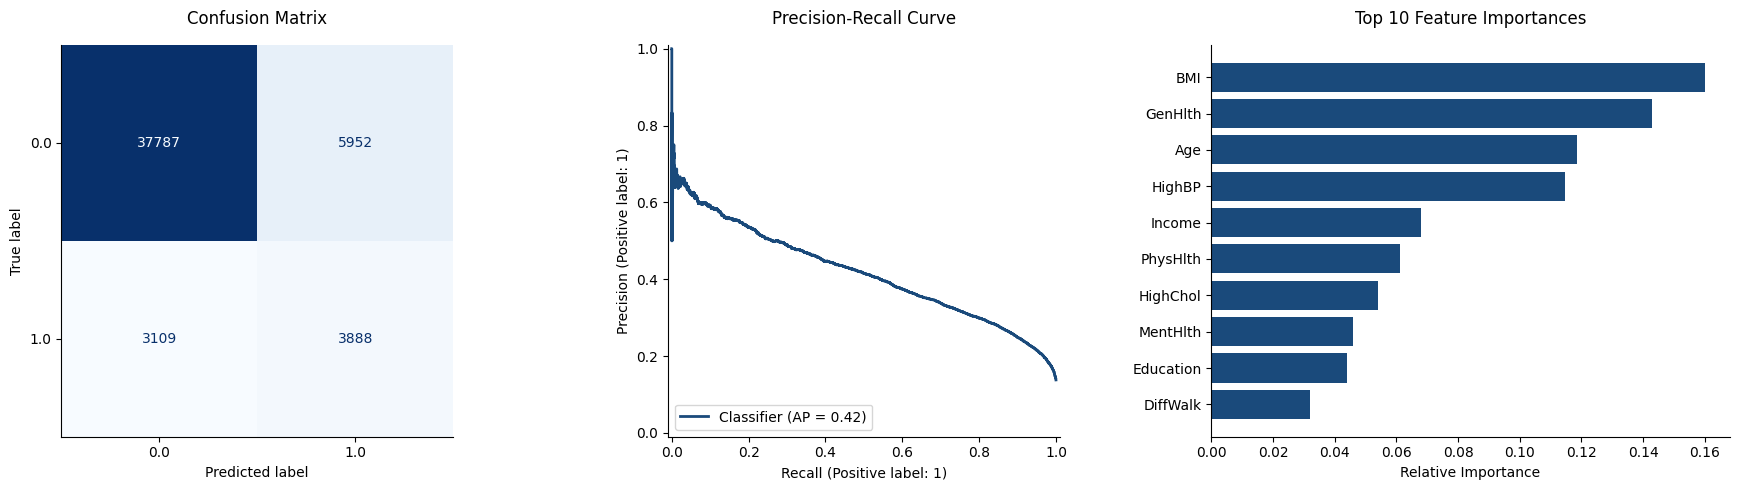

In [101]:
from sklearn.metrics import ConfusionMatrixDisplay, PrecisionRecallDisplay

# 5. Build the Visualizations
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot A: Confusion Matrix
# This shows exactly how many False Positives vs. True Positives you are getting
ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    ax=axes[0], 
    cmap='Blues', 
    colorbar=False
)
axes[0].set_title('Confusion Matrix', pad=15)

# Plot B: Precision-Recall Curve
# This visualizes how your precision changes if you adjust the probability threshold
PrecisionRecallDisplay.from_predictions(
    y_test, 
    y_pred_proba, 
    ax=axes[1], 
    color='#1A4A7B',
    linewidth=2
)
axes[1].set_title('Precision-Recall Curve', pad=15)

# Plot C: Top 10 Feature Importances
# This reveals which columns the model relies on most heavily
importances = optimized_rf.feature_importances_

# Safely extract column names if X_train is a DataFrame
if hasattr(X_train, 'columns'):
    feature_names = X_train.columns
else:
    feature_names = [f"Feature {i}" for i in range(X_train.shape[1])]

# Get indices of the top 10 most important features
top_10_indices = np.argsort(importances)[::-1][:10]
top_10_importances = importances[top_10_indices]
top_10_names = [feature_names[i] for i in top_10_indices]

# Create a horizontal bar chart (reversing order so the highest is at the top)
axes[2].barh(range(10), top_10_importances[::-1], align='center', color='#1A4A7B')
axes[2].set_yticks(range(10))
axes[2].set_yticklabels(top_10_names[::-1])
axes[2].set_title('Top 10 Feature Importances', pad=15)
axes[2].set_xlabel('Relative Importance')

# Clean up layout and display
# Removing top and right spines for a cleaner aesthetic
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

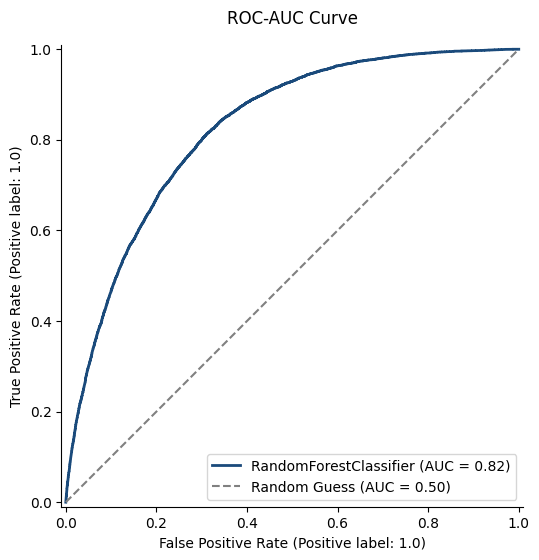

In [66]:
from sklearn.metrics import RocCurveDisplay

# 3. Plot the ROC curve (The simplest way)
fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_estimator(
    optimized_rf, 
    X_test, 
    y_test, 
    ax=ax, 
    color='#1A4A7B',
    linewidth=2
)

# Add the 50/50 random guess line for context
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess (AUC = 0.50)')

plt.title('ROC-AUC Curve', pad=15)
plt.legend(loc='lower right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

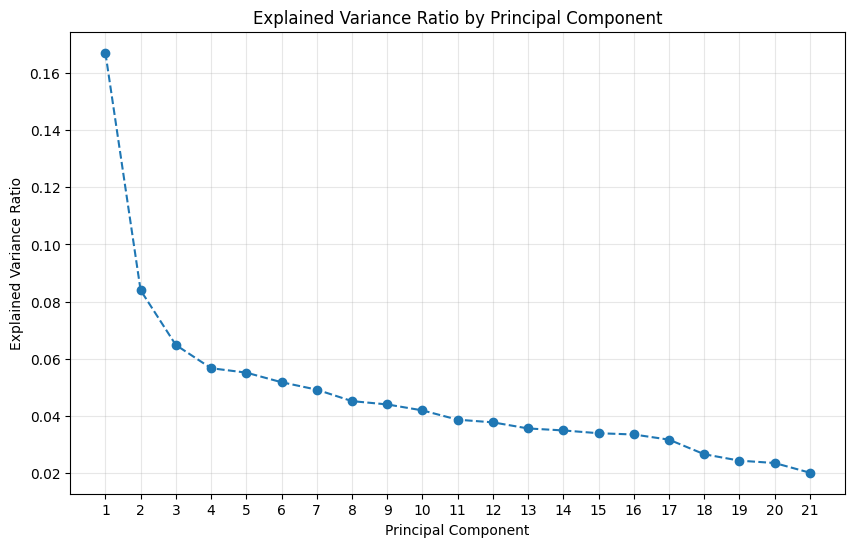

In [74]:
# Import necessary libraries for PCA
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Scale the X variable
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Perform PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Visualize explained variance ratio
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_, marker='o', linestyle='--')
plt.title('Explained Variance Ratio by Principal Component')
plt.xlabel('Principal Component')
plt.xticks(range(1, len(pca.explained_variance_ratio_) + 1))
plt.ylabel('Explained Variance Ratio')
plt.grid(alpha=0.3)
plt.show()


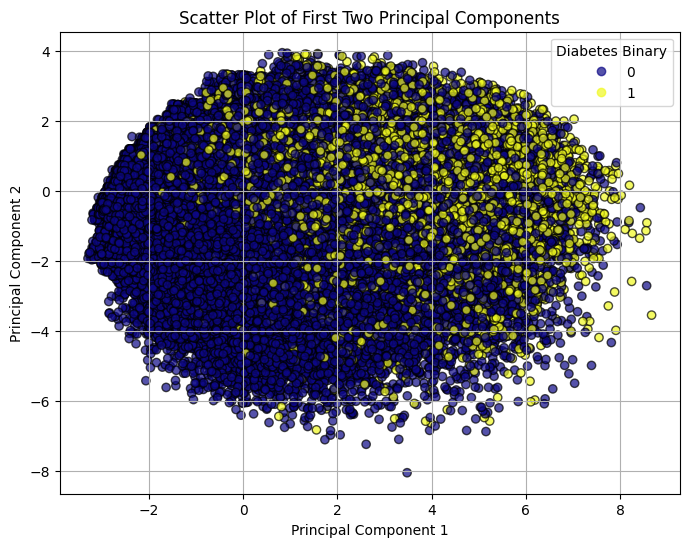

In [99]:
# Create the figure
plt.figure(figsize=(8, 6))

# Capture the scatter object in a variable
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='plasma', alpha=0.7, edgecolor='k')

plt.title('Scatter Plot of First Two Principal Components')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)

# Use legend_elements to extract the groups from the scatter object
# This will automatically map the colors to the unique values in your target variable (y)
handles, labels = scatter.legend_elements()
plt.legend(handles, labels, title="Diabetes Binary", loc='upper right')

plt.show()

# 4. Storytelling With Data plot

Reproduce any graph of your choice in chapter seven (p. 165-185) of the Storytelling With Data book as best you can. You do not have to get the exact data values right, just the overall look and feel.

There are no graphs in Chapter 7. 